# Augmentation Feature Space Outlier Analysis

Goal: test whether augmented images behave like in-distribution training samples or outliers in YOLO feature space.

This notebook compares four image groups:
1. original_train
2. augmented_random (without_score condition)
3. augmented_score (with_score condition)
4. test

Method:
- Load frozen YOLOv8s
- Extract image-level embedding by global average pooling of P4 or P5 feature map
- Visualize 2D projection
- Compute centroid distances to test centroid

In [11]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import random
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [12]:
# ---------------------------
# User inputs
# ---------------------------
PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")
CONFIG_PATH = PROJECT_ROOT / "configs/experiments/minneapple_yolo.yaml"

# Use one seed directory from the score-vs-random comparison experiment
SEED = 123
COMPARE_RESULTS_ROOT = PROJECT_ROOT / "results/12_multiseed_score_vs_noscore_copy_paste_exp_apple_withaug" / f"seed_{SEED}"

# YOLO backbone checkpoint for feature extraction (frozen)
YOLO_WEIGHTS = PROJECT_ROOT / "finetuned_baseline_model/yolov8s.pt"

# Feature level to extract: "P4" or "P5"
FEATURE_LEVEL = "P5"

# Image preprocessing
IMAGE_SIZE = 1024

# Sampling controls
MAX_ORIGINAL_TRAIN = None   # e.g., 670 or None for all
MAX_AUG_RANDOM = None       # e.g., 200 or None for all available
MAX_AUG_SCORE = None        # e.g., 200 or None for all available
MAX_TEST = None             # e.g., 200 or None for all
RANDOM_SEED = 123
ONLY_SYNTHETIC_AUG_IMAGES = True  # Keep only files whose stem starts with 'aug_' for augmented groups

In [13]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rng = random.Random(RANDOM_SEED)


@dataclass
class GroupPaths:
    original_train: Path
    augmented_random: Path
    augmented_score: Path
    test: Path


def load_dataset_dirs_from_config(config_path: Path) -> tuple[Path, Path]:
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    dataset_cfg = cfg.get("dataset_config", {})
    root_dir = Path(dataset_cfg["root_dir"]).resolve()
    train_dir = root_dir / "train/images"
    test_dir = root_dir / "test/images"
    return train_dir, test_dir


def resolve_group_paths(config_path: Path, compare_results_root: Path) -> GroupPaths:
    original_train_dir, test_dir = load_dataset_dirs_from_config(config_path)

    aug_random_dir = compare_results_root / "Step_4_Copy_Paste_Augmentation/without_score/augmented_dataset/train/images"
    aug_score_dir = compare_results_root / "Step_4_Copy_Paste_Augmentation/with_score/augmented_dataset/train/images"

    return GroupPaths(
        original_train=original_train_dir,
        augmented_random=aug_random_dir,
        augmented_score=aug_score_dir,
        test=test_dir,
    )


def list_image_paths(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted([p for p in directory.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])


def filter_augmented_only(paths: list[Path]) -> list[Path]:
    if not ONLY_SYNTHETIC_AUG_IMAGES:
        return paths
    return [p for p in paths if p.stem.startswith("aug_")]


def sample_paths(paths: list[Path], max_count: int | None) -> list[Path]:
    if max_count is None or len(paths) <= max_count:
        return paths
    idx = list(range(len(paths)))
    rng.shuffle(idx)
    keep = set(idx[:max_count])
    return [p for i, p in enumerate(paths) if i in keep]

In [14]:
group_dirs = resolve_group_paths(CONFIG_PATH, COMPARE_RESULTS_ROOT)

group_to_paths: dict[str, list[Path]] = {
    "original_train": list_image_paths(group_dirs.original_train),
    "augmented_random": filter_augmented_only(list_image_paths(group_dirs.augmented_random)),
    "augmented_score": filter_augmented_only(list_image_paths(group_dirs.augmented_score)),
    "test": list_image_paths(group_dirs.test),
}

group_to_paths["original_train"] = sample_paths(group_to_paths["original_train"], MAX_ORIGINAL_TRAIN)
group_to_paths["augmented_random"] = sample_paths(group_to_paths["augmented_random"], MAX_AUG_RANDOM)
group_to_paths["augmented_score"] = sample_paths(group_to_paths["augmented_score"], MAX_AUG_SCORE)
group_to_paths["test"] = sample_paths(group_to_paths["test"], MAX_TEST)

counts_df = pd.DataFrame({
    "group": list(group_to_paths.keys()),
    "n_images": [len(v) for v in group_to_paths.values()],
})
display(counts_df)

if (counts_df["n_images"] == 0).any():
    raise RuntimeError("At least one group has 0 images. Check paths and settings.")

,group,n_images
0,original_train,536
1,augmented_random,160
2,augmented_score,160
3,test,331


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

yolo = YOLO(str(YOLO_WEIGHTS))
model = yolo.model.to(device).eval()
for p in model.parameters():
    p.requires_grad = False

detect_module = model.model[-1]
detect_feature_from = list(getattr(detect_module, "f", []))
if len(detect_feature_from) < 3:
    raise RuntimeError("Could not resolve Detect feature indices for P3/P4/P5.")

feature_index_map = {
    "P3": int(detect_feature_from[-3]),
    "P4": int(detect_feature_from[-2]),
    "P5": int(detect_feature_from[-1]),
}

if FEATURE_LEVEL not in feature_index_map:
    raise ValueError(f"FEATURE_LEVEL must be one of {list(feature_index_map.keys())}")

TARGET_LAYER_INDEX = feature_index_map[FEATURE_LEVEL]
print(f"Using feature level {FEATURE_LEVEL} from model.model[{TARGET_LAYER_INDEX}]")

Using device: cuda
Using feature level P5 from model.model[21]


In [16]:
def preprocess_image_for_yolo(image_path: Path, image_size: int = 1024) -> torch.Tensor:
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise RuntimeError(f"Failed to read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

    x = torch.from_numpy(img_resized).float() / 255.0
    x = x.permute(2, 0, 1).unsqueeze(0)
    return x


def extract_image_embedding(model, image_path: Path, layer_index: int, image_size: int, device: torch.device) -> np.ndarray:
    captured = {}

    def hook_fn(_module, _inputs, output):
        if isinstance(output, (tuple, list)):
            output = output[0]
        captured["feat"] = output

    handle = model.model[layer_index].register_forward_hook(hook_fn)

    try:
        x = preprocess_image_for_yolo(image_path, image_size=image_size).to(device)
        with torch.no_grad():
            _ = model(x)

        feat = captured.get("feat", None)
        if feat is None:
            raise RuntimeError(f"Hook did not capture features for {image_path}")

        if feat.ndim == 4:
            emb = feat.mean(dim=(2, 3)).squeeze(0)
        elif feat.ndim == 2:
            emb = feat.squeeze(0)
        else:
            emb = feat.reshape(feat.shape[0], -1).mean(dim=0)

        return emb.detach().cpu().numpy().astype(np.float32)
    finally:
        handle.remove()

In [17]:
records = []

for group_name, paths in group_to_paths.items():
    print(f"Extracting embeddings: {group_name} ({len(paths)} images)")
    for i, img_path in enumerate(paths, start=1):
        if i % 100 == 0 or i == len(paths):
            print(f"  {i}/{len(paths)}")
        emb = extract_image_embedding(
            model=model,
            image_path=img_path,
            layer_index=TARGET_LAYER_INDEX,
            image_size=IMAGE_SIZE,
            device=device,
        )
        records.append({
            "group": group_name,
            "image_path": str(img_path),
            "embedding": emb,
        })

print(f"Done. Total embeddings: {len(records)}")

Extracting embeddings: original_train (536 images)
  100/536
  200/536
  300/536
  400/536
  500/536
  536/536
Extracting embeddings: augmented_random (160 images)
  100/160
  160/160
Extracting embeddings: augmented_score (160 images)
  100/160
  160/160
Extracting embeddings: test (331 images)
  100/331
  200/331
  300/331
  331/331
Done. Total embeddings: 1187


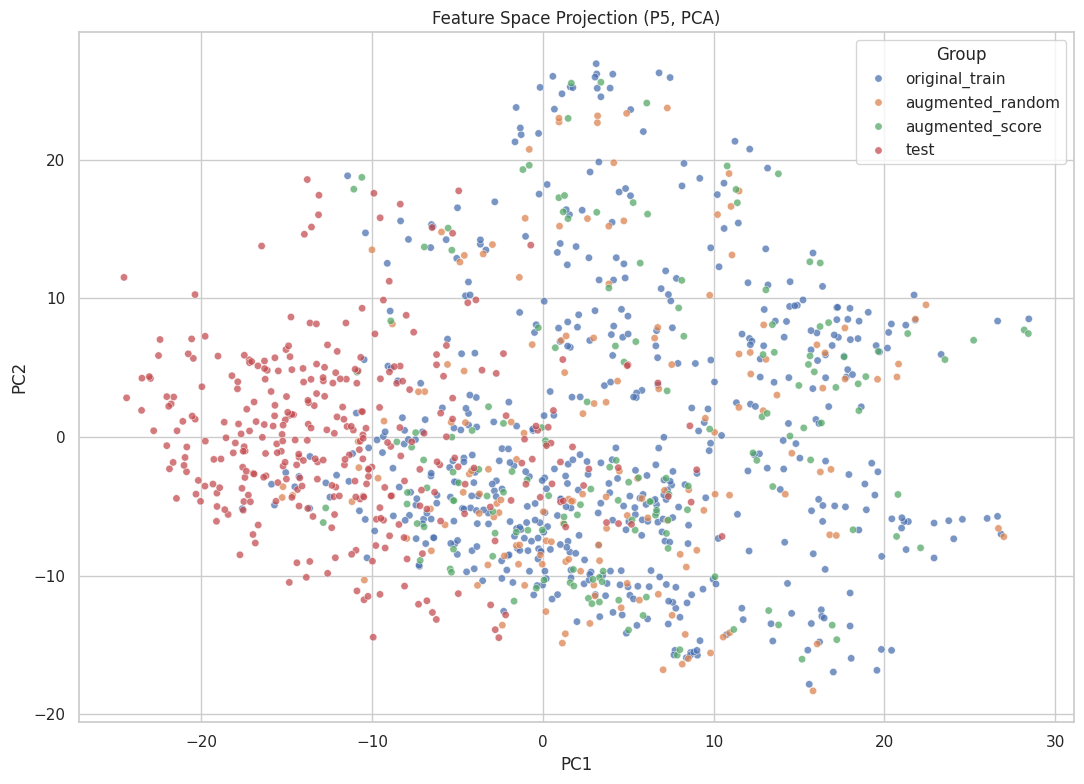

PCA explained variance (2D): 0.395


In [18]:
if not records:
    raise RuntimeError("No embeddings extracted.")

meta_df = pd.DataFrame([{"group": r["group"], "image_path": r["image_path"]} for r in records])
X = np.stack([r["embedding"] for r in records], axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca.fit_transform(X_scaled)

plot_df = meta_df.copy()
plot_df["pc1"] = X_2d[:, 0]
plot_df["pc2"] = X_2d[:, 1]

plt.figure(figsize=(11, 8))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="group", alpha=0.75, s=28)
plt.title(f"Feature Space Projection ({FEATURE_LEVEL}, PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

explained = pca.explained_variance_ratio_.sum()
print(f"PCA explained variance (2D): {explained:.3f}")

In [19]:
group_names = ["original_train", "augmented_random", "augmented_score", "test"]
centroids = {}

for g in group_names:
    idx = np.where(meta_df["group"].values == g)[0]
    if len(idx) == 0:
        raise RuntimeError(f"No embeddings found for group: {g}")
    centroids[g] = X_scaled[idx].mean(axis=0)

def dist(a: np.ndarray, b: np.ndarray, metric: str = "euclidean") -> float:
    return float(pairwise_distances(a[None, :], b[None, :], metric=metric)[0, 0])

d_original_to_test_eu = dist(centroids["original_train"], centroids["test"], metric="euclidean")
d_aug_random_to_test_eu = dist(centroids["augmented_random"], centroids["test"], metric="euclidean")
d_aug_score_to_test_eu = dist(centroids["augmented_score"], centroids["test"], metric="euclidean")

d_original_to_test_cos = dist(centroids["original_train"], centroids["test"], metric="cosine")
d_aug_random_to_test_cos = dist(centroids["augmented_random"], centroids["test"], metric="cosine")
d_aug_score_to_test_cos = dist(centroids["augmented_score"], centroids["test"], metric="cosine")

distance_df = pd.DataFrame([
    {"metric": "euclidean", "original_to_test": d_original_to_test_eu, "aug_random_to_test": d_aug_random_to_test_eu, "aug_score_to_test": d_aug_score_to_test_eu},
    {"metric": "cosine", "original_to_test": d_original_to_test_cos, "aug_random_to_test": d_aug_random_to_test_cos, "aug_score_to_test": d_aug_score_to_test_cos},
])

display(distance_df.round(4))

print(f"Original train -> Test (euclidean): {d_original_to_test_eu:.4f}")
print(f"Augmented random -> Test (euclidean): {d_aug_random_to_test_eu:.4f}")
print(f"Augmented score  -> Test (euclidean): {d_aug_score_to_test_eu:.4f}")

,metric,original_to_test,aug_random_to_test,aug_score_to_test
0,euclidean,16.8058,16.2602,17.3665
1,cosine,1.9919,1.9531,1.9566


Original train -> Test (euclidean): 16.8058
Augmented random -> Test (euclidean): 16.2602
Augmented score  -> Test (euclidean): 17.3665


In [20]:
def verdict_line(name: str, val: float, base: float) -> str:
    if val > base:
        return f"{name}: farther from test than original train ({val:.4f} > {base:.4f})"
    if val < base:
        return f"{name}: closer to test than original train ({val:.4f} < {base:.4f})"
    return f"{name}: same distance as original train ({val:.4f})"

print("Interpretation (euclidean centroid distances):")
print("- " + verdict_line("Augmented random", d_aug_random_to_test_eu, d_original_to_test_eu))
print("- " + verdict_line("Augmented score", d_aug_score_to_test_eu, d_original_to_test_eu))

if d_aug_score_to_test_eu > d_aug_random_to_test_eu:
    print("- Score-guided appears farther from test than random in this feature space.")
elif d_aug_score_to_test_eu < d_aug_random_to_test_eu:
    print("- Score-guided appears closer to test than random in this feature space.")
else:
    print("- Score-guided and random have equal test distance in this feature space.")

Interpretation (euclidean centroid distances):
- Augmented random: closer to test than original train (16.2602 < 16.8058)
- Augmented score: farther from test than original train (17.3665 > 16.8058)
- Score-guided appears farther from test than random in this feature space.
